# some plots from Figures 2 and 3

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import networkx as nx
#from mastodon_reader import MastodonReader

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import colorsys

plt.rcParams.update({'font.size': 18})

In [4]:
import warnings
warnings.filterwarnings('ignore',category=DeprecationWarning)
warnings.filterwarnings('ignore',category=FutureWarning)

In [5]:
def get_trajs_starting_at_node(g,v0):
    trajs=[[v0]]
    trajs_out=[]
    while len(trajs)>0:
        traj=trajs.pop()
        while True:
            outlinks=list(g.out_edges(traj[-1]))
        #print(outlinks)
            if len(outlinks)==1:
                traj.append(outlinks[0][1])
            elif len(outlinks)==0:
                trajs_out.append(traj)
                #print(traj)
                break
            else:
                #traj.append(outlinks[0][1])
                trajs_out.append(traj)
                #print(traj)
                for l in outlinks:
                    trajs.append([traj[-1],l[1]])
                break
    return trajs_out

def get_all_trajs(gragh):
    roots=[node for node, degree in graph.in_degree() if degree == 0]
    trajs=[]
    for v in roots:
        trajs = trajs + get_trajs_starting_at_node(graph,v) 
    return trajs

# Load all necessary data

In [6]:
dat3={'control1':{'file':'../data/brightfield/150h_replicates/1/control/well_B2_5frames_r35_50_50_t116-600.mastodon_bt_graph.gz', 'label':'control'},
       '500uM1':{'file':'../data/brightfield/150h_replicates/1/500um/well_B5_5frames_r35_50_50_t116-600.mastodon_bt_graph.gz', 'label': r'500$\mathrm{\mu}$M'},
        'control2':{'file':'../data/brightfield/150h_replicates/2/control/well_B2_t106-600_5frames_r35-50-50.mastodon_bt_graph.gz', 'label':'control'},
       '500uM2':{'file':'../data/brightfield/150h_replicates/2/500um/well_B5_t106-600_5frames_r35-50-50.mastodon_bt_graph.gz', 'label': r'500$\mathrm{\mu}$M'},
        'control3':{'file':'../data/brightfield/150h_replicates/3/control/well_B2_t120-600_bf_labels_3frames_r35-35-35.mastodon_bt_graph.gz', 'label':'control'},
       '500uM3':{'file':'../data/brightfield/150h_replicates/3/500um/well_B5_t120-600_bf_labels_3frames_r35-35-35.mastodon_bt_graph.gz', 'label': r'500$\mathrm{\mu}$M'}
      }
for e in dat3: 
    dat3[e]['graph'] = nx.read_graphml(dat3[e]['file'])
    print(dat3[e]['graph'].number_of_nodes())
    print(dat3[e]['graph'].number_of_edges())

370419
369192
326580
325560
442094
440454
675087
672404
731751
726626
717881
715901


In [7]:
for e in dat3: 
    graph=dat3[e]['graph']
    mapping={}
    for v in list(graph.nodes):
        mapping[v]=int(v)
    dat3[e]['graph']=nx.relabel_nodes(graph,mapping)
    print("N=",graph.number_of_nodes()," L=",graph.number_of_edges())

N= 370419  L= 369192
N= 326580  L= 325560
N= 442094  L= 440454
N= 675087  L= 672404
N= 731751  L= 726626
N= 717881  L= 715901


In [8]:
dt=1/6.
col={}
col['control1']='green'
col['500uM1']='red'
col['control2']='green'
col['500uM2']='red'
col['control3']='green'
col['500uM3']='red'

In [9]:
def get_avg_speed_2(graph,trajs,step=1):
    speeds = []
    for traj in trajs:
        if len(traj)>10: # only trajectories with more than this many nodes are taken
            xyt=np.array([[graph.nodes[v]['x'],graph.nodes[v]['y'],graph.nodes[v]['t']*dt] for v in traj])
            #dxyt = np.diff(xyt,axis=0)
            dxyt=xyt[step::]-xyt[0:-step:]
            #dxyt=np.diff(xyt[::step],axis=0)
            dr = np.sqrt(dxyt[:,0]**2 + dxyt[:,1]**2)
            speed = dr/dxyt[:,2]
            avg_speed = np.nanmean(speed,axis=0)
            speeds.append(avg_speed)
    return np.array(speeds) # speeds are in um/h

In [10]:
dat2=dat3

# ---------skip all this until ------ "start here" -----------

0.49209051613637883
0.5259966744083502
0.5308174119191578
0.573032008578521
0.5609956377379529
0.5441987139437197


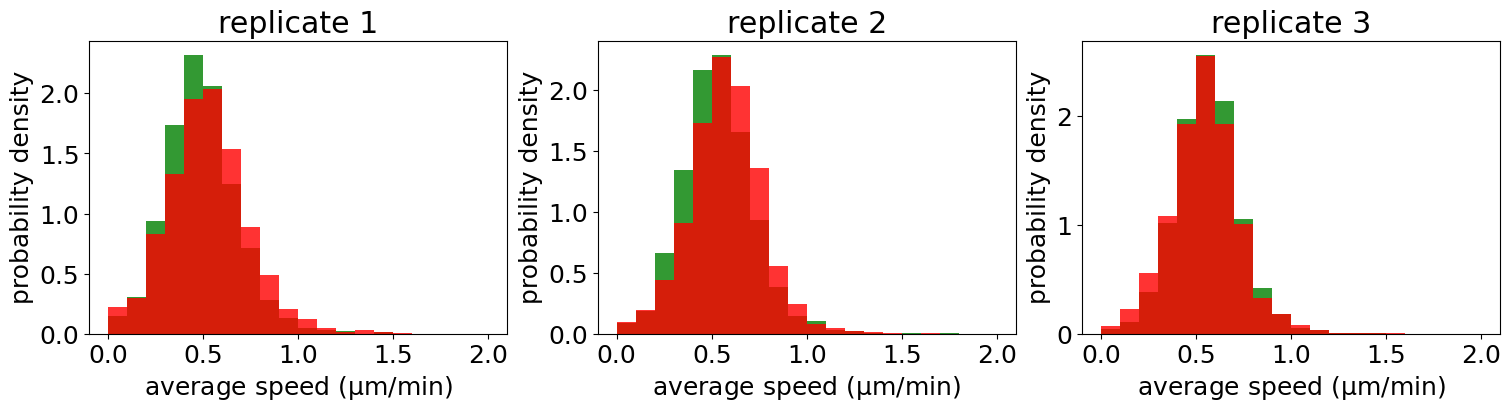

In [21]:
fig,ax = plt.subplots(1,3,figsize=(15,4),layout='constrained',squeeze=False)
j=0
for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    speeds=get_avg_speed_2(graph,trajs,3)/60. # convert from um/h to um/min
    print(np.mean(speeds))
    #speeds=np.random.rand(100)
    ax[0][j//2].hist(speeds,bins=20,range=(0,2),color=col[e],label=dat2[e]['label'],density=True,alpha=0.8)

    ax[0][j//2].set_title("replicate "+str(1+j//2))
    ax[0][j//2].set_xlabel('average speed ($\mathrm{\mu}$m/min)')
    ax[0][j//2].set_ylabel('probability density')
    j+=1
#plt.savefig('../figures/plots/histogram_lifespans_{}.svg'.format(exp_label))
#plt.savefig('../figures/plots/distributions_avg_speed_3reps_separate.svg')#,bbox_inches='constrained')
plt.show()

0.49209051613637883
0.5259966744083502
0.5308174119191578
0.573032008578521
0.5609956377379529
0.5441987139437197


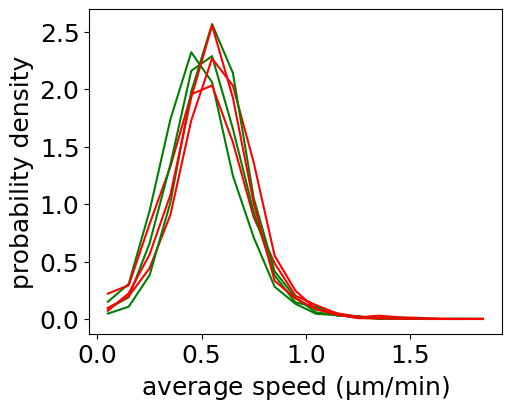

In [22]:
fig,ax = plt.subplots(1,1,figsize=(5,4),layout='constrained',squeeze=False)

for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    speeds=get_avg_speed_2(graph,trajs,3)/60. # convert from um/h to um/min
    print(np.mean(speeds))
    #speeds=np.random.rand(100)
    c,b =np.histogram(speeds,bins=np.arange(0,2.0,0.1),density=True)
    ax[0][0].plot((b[1:]+b[:-1])*0.5,c,color=col[e],label=dat2[e]['label'])

    
ax[0][0].set_xlabel('average speed ($\mathrm{\mu}$m/min)')
ax[0][0].set_ylabel('probability density')

#plt.savefig('../figures/plots/histogram_lifespans_{}.svg'.format(exp_label))
#plt.savefig('../figures/plots/distributions_avg_speed_3reps_oneplot.svg')#,bbox_inches='constrained')
plt.show()

0.48222939063975057
0.560532006310651
0.517307373859913
0.5951662608446673
0.5511244908767596
0.5691639492180505


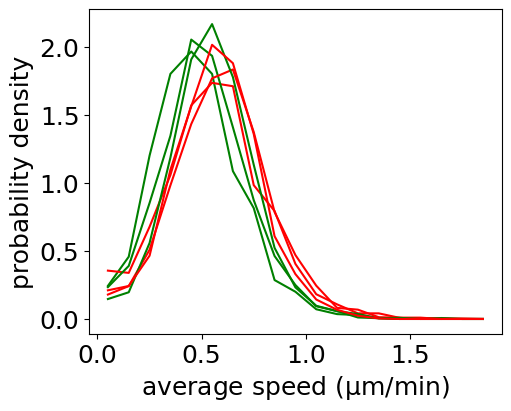

In [23]:
fig,ax = plt.subplots(1,1,figsize=(5,4),layout='constrained',squeeze=False)

for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    trajs=[[v for v in traj if (graph.nodes[v]['t']>40*6 and graph.nodes[v]['t']<60*6)] for traj in trajs]
    speeds=get_avg_speed_2(graph,trajs,3)/60. # convert from um/h to um/min
    print(np.mean(speeds))
    #speeds=np.random.rand(100)
    c,b =np.histogram(speeds,bins=np.arange(0,2.0,0.1),density=True)
    ax[0][0].plot((b[1:]+b[:-1])*0.5,c,color=col[e],label=dat2[e]['label'])

    
ax[0][0].set_xlabel('average speed ($\mathrm{\mu}$m/min)')
ax[0][0].set_ylabel('probability density')

#plt.savefig('../figures/plots/histogram_lifespans_{}.svg'.format(exp_label))
#plt.savefig('../figures/plots/distributions_avg_speed_3reps_midtime_oneplot.svg')#,bbox_inches='constrained')
plt.show()

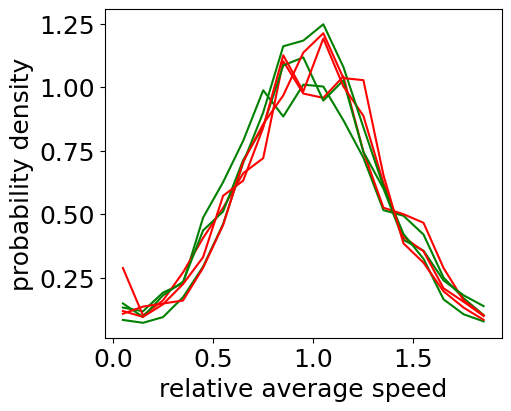

In [24]:
# relative velocity
fig,ax = plt.subplots(1,1,figsize=(5,4),layout='constrained',squeeze=False)

for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    trajs=[[v for v in traj if (graph.nodes[v]['t']>40*6 and graph.nodes[v]['t']<60*6)] for traj in trajs]
    speeds=get_avg_speed_2(graph,trajs,3)/60. # convert from um/h to um/min
    speeds=speeds/np.mean(speeds)
    
    #speeds=np.random.rand(100)
    c,b =np.histogram(speeds,bins=np.arange(0,2.0,0.1),density=True)
    ax[0][0].plot((b[1:]+b[:-1])*0.5,c,color=col[e],label=dat2[e]['label'])

    
ax[0][0].set_xlabel('relative average speed')
ax[0][0].set_ylabel('probability density')

#plt.savefig('../figures/plots/histogram_lifespans_{}.svg'.format(exp_label))
#plt.savefig('../figures/plots/distributions_relative_avg_speed_3reps_midtime_oneplot.svg')#,bbox_inches='constrained')
plt.show()

1.39960356797961
1.572688253428891
1.4740482562876212
1.6933361799036033
1.5486293989723554
1.7786181985692633


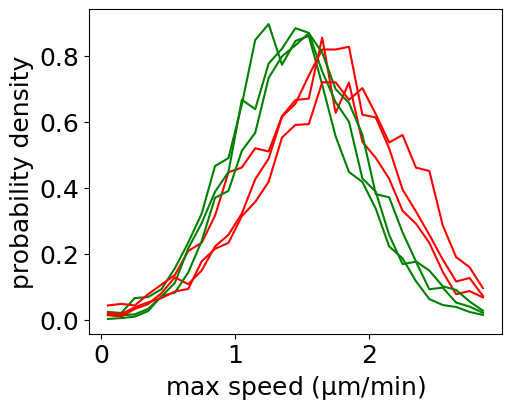

In [27]:
# maximum speed along a trajectory, all times
fig,ax = plt.subplots(1,1,figsize=(5,4),layout='constrained',squeeze=False)

for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    #trajs=[[v for v in traj if (graph.nodes[v]['t']>40*6 and graph.nodes[v]['t']<60*6)] for traj in trajs]
    #speeds=get_avg_speed_2(graph,trajs,3)/60. # convert from um/h to um/min
    vels=get_speed_2(graph,trajs,3)
    #print(vels[0])
    speeds=[np.max(np.array(tr)[:,1])/60. for tr in vels]
    print(np.mean(speeds))
    #speeds=np.random.rand(100)
    c,b =np.histogram(speeds,bins=np.arange(0,3.0,0.1),density=True)
    ax[0][0].plot((b[1:]+b[:-1])*0.5,c,color=col[e],label=dat2[e]['label'])

    
ax[0][0].set_xlabel('max speed ($\mathrm{\mu}$m/min)')
ax[0][0].set_ylabel('probability density')

#plt.savefig('../figures/plots/histogram_lifespans_{}.svg'.format(exp_label))
#plt.savefig('../figures/plots/distributions_avg_speed_3reps_midtime_oneplot.svg')#,bbox_inches='constrained')
plt.show()

0.48408434894974656
0.5377659782120722
0.514499181797662
0.5691025957679888
0.5482435163201439
0.5615487912209481


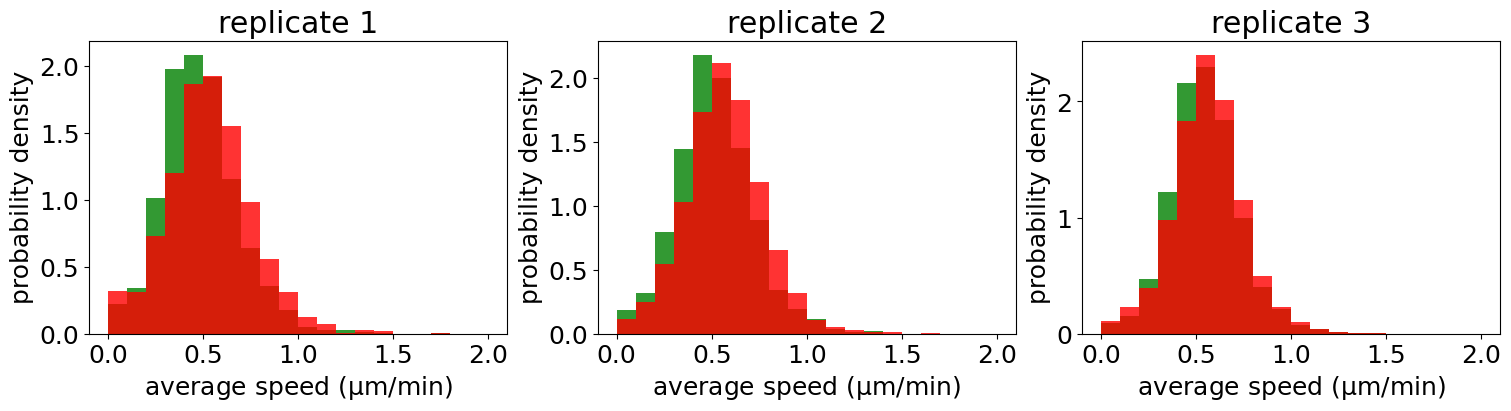

In [28]:
fig,ax = plt.subplots(1,3,figsize=(15,4),layout='constrained',squeeze=False)
j=0
for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    trajs=[[v for v in traj if (graph.nodes[v]['t']>100 and graph.nodes[v]['t']<400)] for traj in trajs]
    speeds=get_avg_speed_2(graph,trajs,3)/60. # convert from um/h to um/min
    print(np.mean(speeds))
    #speeds=np.random.rand(100)
    ax[0][j//2].hist(speeds,bins=20,range=(0,2),color=col[e],label=dat2[e]['label'],density=True,alpha=0.8)

    ax[0][j//2].set_title("replicate "+str(1+j//2))
    ax[0][j//2].set_xlabel('average speed ($\mathrm{\mu}$m/min)')
    ax[0][j//2].set_ylabel('probability density')
    j+=1
#plt.savefig('../figures/plots/histogram_lifespans_{}.svg'.format(exp_label))
#plt.savefig('../figures/plots/distributions_avg_speed_3reps_midtime_separate.svg')#,bbox_inches='constrained')
plt.show()

0.5180928377921953
0.5331505603451875


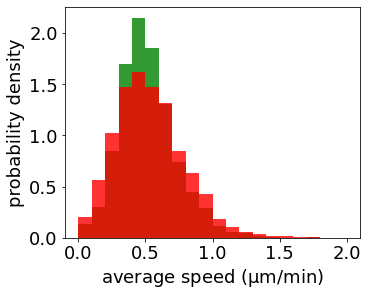

In [297]:
# smaller data set (centre of well only)
fig,ax = plt.subplots(figsize=(5,4),layout='constrained',squeeze=False)
for e in dat:
    graph=dat[e]['graph']
    trajs=get_all_trajs(graph)
    speeds=get_avg_speed_2(graph,trajs,3)/60. # convert from um/h to um/min
    print(np.mean(speeds))
    ax[0][0].hist(speeds,bins=20,range=(0,2),color=col[e],label=dat[e]['label'],density=True,alpha=0.8)

ax[0][0].set_xlabel('average speed ($\mathrm{\mu}$m/min)')
ax[0][0].set_ylabel('probability density')
#plt.savefig('../figures/plots/histogram_lifespans_{}.svg'.format(exp_label))
plt.show()

In [37]:
def get_speed_2(graph,trajs,step=1):
    speeds = []
    for traj in trajs:
        if len(traj)>10: # only trajectories with more than this many nodes are taken
            xyt=np.array([[graph.nodes[v]['x'],graph.nodes[v]['y'],graph.nodes[v]['t']*dt] for v in traj])
            # convert from um/h to um/min
            speed = [[xyt[i,2],(1/60.)*np.sqrt((xyt[i+step,0]-xyt[i,0])**2 + (xyt[i+step,1]-xyt[i,1])**2)/(xyt[i+step,2]-xyt[i,2])] 
                      for i in range(0,len(xyt)-step,step)]
            speeds.append(speed)
    return speeds # speeds are in um/h

def bin_xy_data(data,qx=1,dropnan=False,bincounts=False):
    from numpy.ma import MaskedArray
    # data in the form of a list of pairs of lists [x] and [y] of coordinates
    xx,yy=[[]],[[]]
    for n,d in enumerate(data):
        d=np.array(d)
        x,y=d[:,0],d[:,1]
        for i in range(0,len(x)):
            if dropnan is True:                
                if (np.isnan(x[i]) or np.isnan(y[i])
                    or isinstance(x[i],MaskedArray)
                    or isinstance(y[i],MaskedArray)) :
                    continue
            j=int(x[i]/qx)
            if (j<len(xx)):
                yy[j].append(y[i])
                xx[j].append(x[i])
            else:
                yy.append([])
                xx.append([])
    # if dropnan:
    #     return [np.nanmean(x) for x in xx],[np.nanmean(y) for y in yy], [np.std(y)/np.sqrt(sum(~np.isnan(y))) for y in yy]
    if bincounts:
        return [np.mean(x) for x in xx],[np.mean(y) for y in yy],[np.std(y)/np.sqrt(len(y)) for y in yy],[ len(x) for x in xx]
    return [np.mean(x) for x in xx],[np.mean(y) for y in yy],[np.std(y)/np.sqrt(len(y)) for y in yy]

# Fig. 3A

/home/bwaclaw/miniconda3/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/bwaclaw/miniconda3/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/bwaclaw/miniconda3/lib/python3.8/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/bwaclaw/miniconda3/lib/python3.8/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/home/bwaclaw/miniconda3/lib/python3.8/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/bwaclaw/miniconda3/lib/python3.8/site-packages/numpy/core/_methods.py

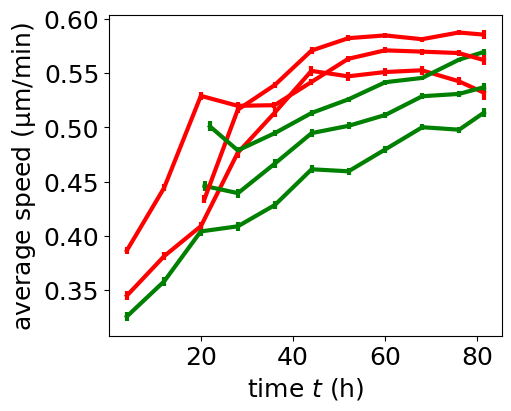

In [38]:
fig,ax = plt.subplots(1,1,figsize=(5,4),layout='constrained',squeeze=False)
for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    vels=get_speed_2(graph,trajs,3)
    
    x,y,err = bin_xy_data(vels,qx=8) 

    ax[0][0].errorbar(x,y,err,lw=3,color=col[e],label=dat2[e]['label'])
    #ax[0][0].set_title("replicate "+str(1+j//2))
ax[0][0].set_xlabel('time $t$ (h)')
ax[0][0].set_ylabel('average speed ($\mathrm{\mu}$m/min)')
plt.savefig('../figures/plots/avg_speed_vs_time_3reps.svg')
plt.show()

# ------------start here ----------------

18.754717710750192
27.55034593526069
17.76035790112223
23.03694184054027
14.857858026774664
30.90830936401406


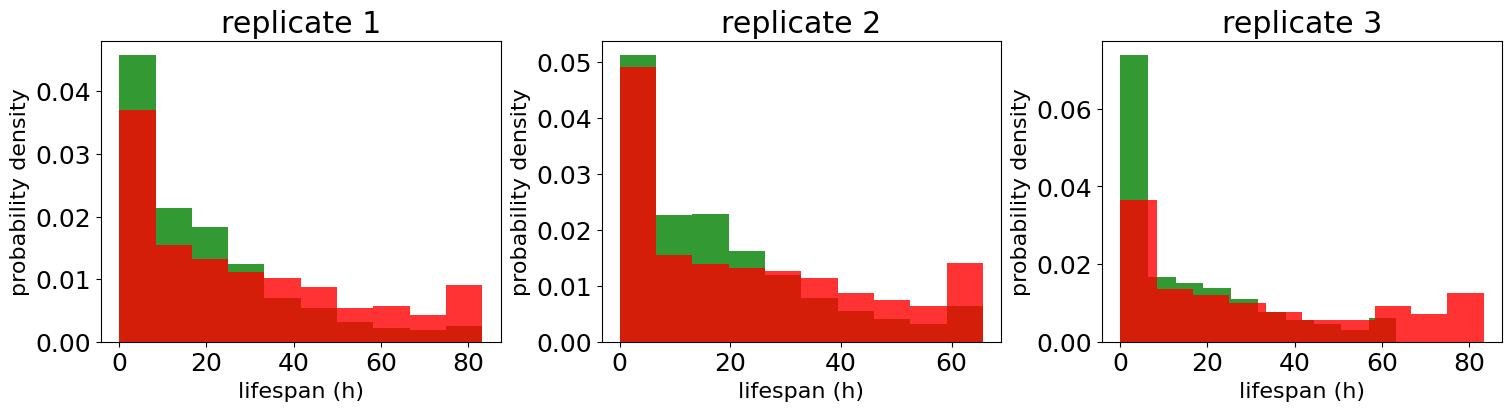

In [49]:
fig,ax = plt.subplots(1,3,figsize=(15,4),layout='constrained',squeeze=False)
j=0
for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    lifespans=[(graph.nodes[tr[-1]]['t']-graph.nodes[tr[0]]['t'])/6. for tr in trajs]
    print(np.mean(lifespans))
    #speeds=np.random.rand(100)
    ax[0][j//2].hist(lifespans,color=col[e],label=dat2[e]['label'],density=True,alpha=0.8)

    ax[0][j//2].set_title("replicate "+str(1+j//2))
    ax[0][j//2].set_xlabel('lifespan (h)',fontsize=16)
    ax[0][j//2].set_ylabel('probability density',fontsize=16) 
    j+=1
#plt.savefig('../figures/plots/histogram_lifespans_{}.svg'.format(exp_label))
#plt.savefig('../figures/plots/xxxx.svg')#,bbox_inches='constrained')
plt.show()

# Fig. 2D

18.754717710750192
27.55034593526069
17.76035790112223
23.03694184054027
14.857858026774664
30.90830936401406


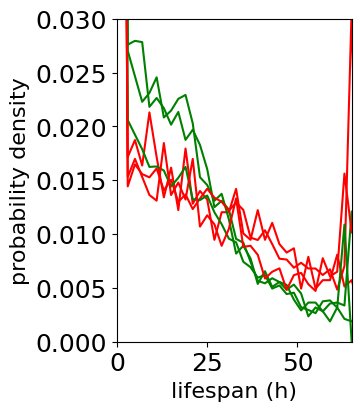

In [24]:
fig,ax = plt.subplots(1,1,figsize=(3.5,4),layout='constrained',squeeze=False)
for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    lifespans=[(graph.nodes[tr[-1]]['t']-graph.nodes[tr[0]]['t'])/6. for tr in trajs]
    print(np.mean(lifespans))
    
    c,b =np.histogram(lifespans,bins=np.arange(0,80,2),density=True)
    ax[0][0].plot((b[1:]+b[:-1])*0.5,c,color=col[e],label=dat2[e]['label'])    #ax[0][0].set_title("replicate "+str(1+j//2))
ax[0][0].set_xlabel('lifespan (h)',fontsize=16)
ax[0][0].set_ylabel('probability density',fontsize=16) 
ax[0][0].set_ylim(0,0.03)
ax[0][0].set_xlim(0,65)
#plt.savefig('../figures/plots/lifespan.svg')
plt.show()


# Fig. 2E: doubling time

20.293292859207863
22.759111994698472
16.519318181818182
15.715634218289086
14.657493028034638
20.381052631578946


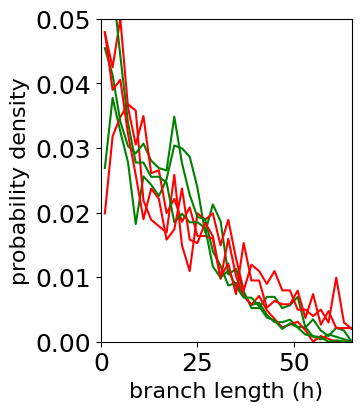

In [25]:
fig,ax = plt.subplots(1,1,figsize=(3.5,4),layout='constrained',squeeze=False)
for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    doubling_times=[(graph.nodes[tr[-1]]['t']-graph.nodes[tr[0]]['t'])/6. for tr in trajs if (graph.degree(tr[0])>=3 and graph.degree(tr[-1])>=3)]
    print(np.mean(doubling_times))
    c,b =np.histogram(doubling_times,bins=np.arange(0,80,2),density=True)
    ax[0][0].plot((b[1:]+b[:-1])*0.5,c,color=col[e],label=dat2[e]['label'])    #ax[0][0].set_title("replicate "+str(1+j//2))
ax[0][0].set_xlabel('branch length (h)',fontsize=16)
ax[0][0].set_ylabel('probability density',fontsize=16) 
ax[0][0].set_ylim(0,0.05)
ax[0][0].set_xlim(0,65)
#plt.savefig('../figures/plots/distribution_doubling_time.svg')
plt.show()

# Fig. 3D: branch length vs speed (NOT OK)

In [53]:
tlim = {'control1':115*6.,
        '500uM1':115*6.,
        'control2':106*6.,
        '500uM2':106*6.,
        'control3':121*6.,
        '500uM3':121*6.,
        } 

In [12]:
#NEW 
def get_speed_2(graph,trajs,step=1):
    dt=1/6
    speeds = []
    for traj in trajs:
        if len(traj)>10: # only trajectories with more than this many nodes are taken
            xyt=np.array([[graph.nodes[v]['x'],graph.nodes[v]['y'],graph.nodes[v]['t']*dt] for v in traj])
            speed = [[xyt[i,2],(1/60.)*np.sqrt((xyt[i+step,0]-xyt[i,0])**2 + (xyt[i+step,1]-xyt[i,1])**2)/(xyt[i+step,2]-xyt[i,2])] 
                      for i in range(0,len(xyt)-step,step)]
            speeds.append(speed)
    return speeds # speed s are in um/min
    
branch_vs_speeds = {} 

for e in dat3:
    graph=dat3[e]['graph']
    trajs=get_all_trajs(graph)
    maxt = max(n['t'] for k,n in graph.nodes(data=True))
    mint = min(n['t'] for k,n in graph.nodes(data=True))
    trajs = [ tr for tr in trajs if len(tr) > 20]
#    trajs = [ tr for tr in trajs if (graph.nodes[tr[-1]]['t']- graph.nodes[tr[0]]['t']) < maxt - mint ]
    # remove trajectories which continue past the end of the experiment
    trajs = [ tr for tr in trajs if graph.nodes[tr[-1]]['t'] < maxt  ]
    #trajs = [ tr for tr in trajs if (graph.nodes[tr[-1]]['t']- graph.nodes[tr[0]]['t']) < tlim[e] ]
    lifespans=[(graph.nodes[tr[-1]]['t']-graph.nodes[tr[0]]['t'])/6. for tr in trajs]
    mean_speed = np.array([np.mean(x,axis=0)[1] for x in get_speed_2(graph,trajs,3)])
    assert len(lifespans) == len(mean_speed)
    branch_vs_speeds[e] = np.array([lifespans,mean_speed])


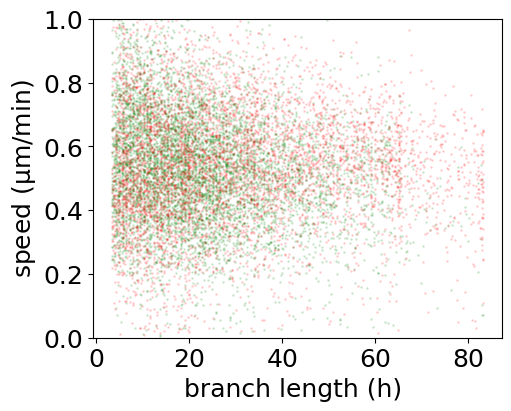

In [30]:

def average_over_x2(data,binx=1):
    data=np.array(data)
    # averages data[i] = [x[i],y[i]] over x
    ylist=[[] for i in range(0,int(max(data[:,0])/binx)+1)]
    xlist=[[] for i in range(0,int(max(data[:,0])/binx)+1)]
    for d in data:
        i=int(d[0]/binx)
        ylist[i].append(d[1])
        xlist[i].append(d[0])
    x=np.array([np.mean(xl) for xl in xlist if len(xl)>0])
    y=np.array([np.mean(yl) for yl in ylist if len(yl)>0])
    err=np.array([np.std(yl)/np.sqrt(1.*len(yl)) for yl in ylist if len(yl)>0])
    std=np.array([np.std(yl) for yl in ylist if len(yl)>0])
    return x,y,err,std

cnts = 0
fig,ax = plt.subplots(1,figsize=(5,4),layout='constrained')
for j,cnd in enumerate(['control','500uM']):
    xs,ys,errs = [],[],[]
    keys = [ k for k in dat3 if cnd in k ]
    for i,(k,branch_vs_speed) in enumerate([(k,branch_vs_speeds[k]) for k in keys]):
        x,y = branch_vs_speed
        ax.scatter(x,y,s=1,alpha=0.13,color=col[k])
        xs.append(x)
        ys.append(y) 
        cnts += len(x)
    xavg,yavg,yerrs,_ =  average_over_x2(np.array([np.concatenate(xs),np.concatenate(ys)]).T,binx=1)
    #ax.plot(xs,ys,lw=1.5,color='darkgreen' if cnd == 'control' else 'red')
    #ax.errorbar(xavg,yavg,yerrs,lw=1.5,color='darkgreen' if cnd == 'control' else 'red')
    #ax.set_ylim(0,0.8)
ax.set_xlabel('branch length (h) ')
ax.set_ylabel('speed ($\mathrm{\mu}$m/min)')
ax.set_ylim(0,1)  
#plt.savefig('../figures/plots/speed_vs_area_3reps.svg')
#plt.gcf().set_dpi(300)
#plt.savefig('/tmp/speed_vs_area_3reps.svg')
plt.show()


# Fig. 3F: mother-daughter speed correlations

n_divs =  1402
PearsonRResult(statistic=0.6780041228894754, pvalue=1.7618207913419717e-63)


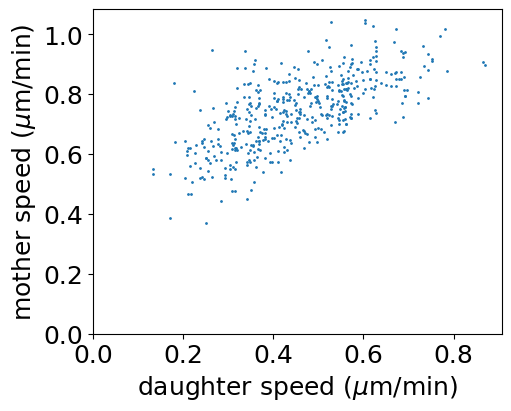

In [15]:
# alternative way
import scipy.stats as stats

def mother_daughter_speed(graph):
    cutofflen=100
    step=3 # for velocity undersampling
    divs=[v for v in graph.nodes() if (graph.out_degree(v)==2)] # and graph.nodes[v]['division_NAME']=='true')]
    vs1,vs2=[],[]
    vvs1,vvs2=[],[]
    divs_included=[]
    print("n_divs = ",len(divs))
    for v0 in divs:
        v=v0
        mother=[]
        while True:
            mother.append(v)
            v=list(graph.predecessors(v))
            #if (len(v)>1):
            #    xxx
            if len(v)==0:
                break
            if graph.out_degree(v[0])>1:
                mother.append(v[0])
                break
            else:
                v=v[0]
        mother=np.flip(mother)

        for v in list(graph.successors(v0)):
            daughter=[]
            while True:
                daughter.append(v)
                v=list(graph.successors(v))
                if len(v)==0:
                    break
                if graph.out_degree(v[0])>1:
                    daughter.append(v[0])
                    break
                else:
                    v=v[0]

            if (len(mother)>cutofflen and len(daughter)>cutofflen):
                divs_included.append(v0)
                xyt=np.array([[graph.nodes[v]['x'],graph.nodes[v]['y'],graph.nodes[v]['t']*dt] for v in mother])
                v1 = np.mean([[xyt[i,2],np.sqrt((xyt[i+step,0]-xyt[i,0])**2 + (xyt[i+step,1]-xyt[i,1])**2)/(xyt[i+step,2]-xyt[i,2])] for i in range(0,len(xyt)-step,step)])
                xyt=np.array([[graph.nodes[v]['x'],graph.nodes[v]['y'],graph.nodes[v]['t']*dt] for v in daughter])
                v2 = np.mean([[xyt[i,2],np.sqrt((xyt[i+step,0]-xyt[i,0])**2 + (xyt[i+step,1]-xyt[i,1])**2)/(xyt[i+step,2]-xyt[i,2])] for i in range(0,len(xyt)-step,step)])
                if (np.isfinite(v1) and np.isfinite(v2)):
                    vvs1.append(v1/60) # um/min
                    vvs2.append(v2/60) # um/min
    return vvs1,vvs2

#graph=dat['500uM']['graph']
graph=dat3['control1']['graph']


fig, ax = plt.subplots(figsize=(5,4),layout='constrained')   

vvs1,vvs2=mother_daughter_speed(graph)
                        
ax.scatter(vvs1,vvs2,s=1)
print(stats.pearsonr(vvs1,vvs2))
ax.set_ylim(0,)
ax.set_xlim(0,)
ax.set_ylabel("mother speed ($\mu$m/min)")
ax.set_xlabel("daughter speed ($\mu$m/min)")
#plt.savefig(currdir+'\\mother_daugther_speed.png',dpi=300)
plt.show()            

n_divs =  1402
PearsonRResult(statistic=0.6780041228894754, pvalue=1.7618207913419717e-63)
n_divs =  763
PearsonRResult(statistic=0.590331377247211, pvalue=3.7262442779611124e-31)
n_divs =  1720
PearsonRResult(statistic=0.4979938626520454, pvalue=5.080277386702797e-26)
n_divs =  1782
PearsonRResult(statistic=0.3413560637334356, pvalue=6.4172189833307206e-15)
n_divs =  2811
PearsonRResult(statistic=0.5454071972161172, pvalue=5.142378587929199e-40)
n_divs =  1474
PearsonRResult(statistic=0.6097370364257881, pvalue=6.224583227814666e-60)


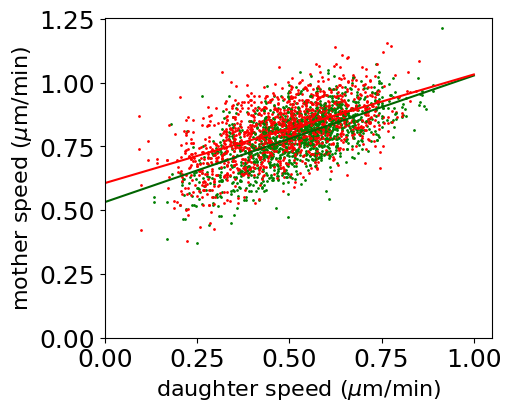

In [31]:
fig,ax = plt.subplots(figsize=(5,4),layout='constrained')
all_coeffs = {'control':[],'500uM':[]}
for e in dat2:
    graph=dat2[e]['graph']
    vvs1,vvs2=mother_daughter_speed(graph)
    ax.scatter(vvs1,vvs2,s=1,c=col[e]) 
    print(stats.pearsonr(vvs1,vvs2))
    coeffs=np.polyfit(vvs1,vvs2,1)
    for k in all_coeffs:
        if k in e: 
            all_coeffs[k].append(coeffs)

for k,coeffs in all_coeffs.items():
    coeffs = np.mean(coeffs,axis=0)
    ax.plot([0,1],[coeffs[1],coeffs[0]+coeffs[1]],c='red' if k == '500uM' else 'darkgreen')
ax.set_xlabel("daughter speed ($\mu$m/min)",fontsize=16)
ax.set_ylabel("mother speed ($\mu$m/min)",fontsize=16) 
ax.set_ylim(0,)
ax.set_xlim(0,)
#plt.savefig('../figures/plots/speed_mother_daughter.svg')
plt.show()

n_divs =  1402
PearsonRResult(statistic=-0.1933957090836232, pvalue=1.2426764531534935e-18)


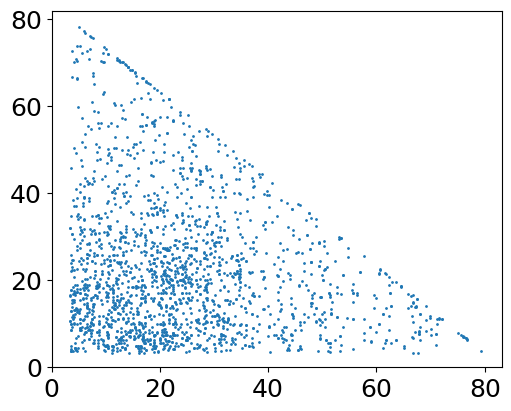

In [17]:
def mother_daughter_lifespan(graph):
    cutofflen=20
    divs=[v for v in graph.nodes() if (graph.out_degree(v)==2)] # and graph.nodes[v]['division_NAME']=='true')]
    lfs1,lfs2=[],[]
    divs_included=[]
    print("n_divs = ",len(divs))
    for v0 in divs:
        v=v0
        mother=[]
        while True:
            mother.append(v)
            v=list(graph.predecessors(v))
            #if (len(v)>1):
            #    xxx
            if len(v)==0:
                break
            if graph.out_degree(v[0])>1:
                mother.append(v[0])
                break
            else:
                v=v[0]
        mother=np.flip(mother)

        for v in list(graph.successors(v0)):
            daughter=[]
            while True:
                daughter.append(v)
                v=list(graph.successors(v))
                if len(v)==0:
                    break
                if graph.out_degree(v[0])>1:
                    daughter.append(v[0])
                    break
                else:
                    v=v[0]

            if (len(mother)>cutofflen and len(daughter)>cutofflen):
                divs_included.append(v0)
                lfs1.append((graph.nodes[mother[-1]]['t']-graph.nodes[mother[0]]['t'])/6.)
                lfs2.append((graph.nodes[daughter[-1]]['t']-graph.nodes[daughter[0]]['t'])/6.)
#                xyt=np.array([[graph.nodes[v]['x'],graph.nodes[v]['y'],graph.nodes[v]['t']*dt] for v in mother])
#                v1 = np.mean([[xyt[i,2],np.sqrt((xyt[i+step,0]-xyt[i,0])**2 + (xyt[i+step,1]-xyt[i,1])**2)/(xyt[i+step,2]-xyt[i,2])] for i in range(0,len(xyt)-step,step)])
#                xyt=np.array([[graph.nodes[v]['x'],graph.nodes[v]['y'],graph.nodes[v]['t']*dt] for v in daughter])
#                v2 = np.mean([[xyt[i,2],np.sqrt((xyt[i+step,0]-xyt[i,0])**2 + (xyt[i+step,1]-xyt[i,1])**2)/(xyt[i+step,2]-xyt[i,2])] for i in range(0,len(xyt)-step,step)])
#                if (np.isfinite(v1) and np.isfinite(v2)):
#                    vvs1.append(v1/60) # um/min
#                    vvs2.append(v2/60) # um/min
    return lfs1,lfs2

#graph=dat['500uM']['graph']
graph=dat3['control1']['graph']


fig, ax = plt.subplots(figsize=(5,4),layout='constrained')   

lfs1,lfs2=mother_daughter_lifespan(graph)
                        
ax.scatter(lfs1,lfs2,s=1)
print(stats.pearsonr(lfs1,lfs2))
ax.set_ylim(0,)
ax.set_xlim(0,)
#ax.set_ylabel("mother speed ($\mu$m/min)")
#ax.set_xlabel("daughter speed ($\mu$m/min)")
#plt.savefig(currdir+'\\mother_daugther_speed.png',dpi=300)
plt.show()            

n_divs =  1402
PearsonRResult(statistic=-0.06262575388642279, pvalue=0.18480662841729434)


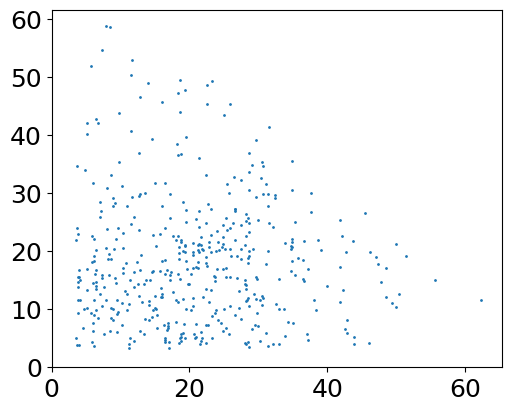

In [18]:
def mother_daughter_DT(graph):
    cutofflen=20
    divs=[v for v in graph.nodes() if (graph.out_degree(v)==2)] # and graph.nodes[v]['division_NAME']=='true')]
    lfs1,lfs2=[],[]
    divs_included=[]
    print("n_divs = ",len(divs))
    for v0 in divs:
        v=v0
        mother=[]
        while True:
            mother.append(v)
            v=list(graph.predecessors(v))
            #if (len(v)>1):
            #    xxx
            if len(v)==0:
                break
            if graph.out_degree(v[0])>1:
                mother.append(v[0])
                break
            else:
                v=v[0]
        mother=np.flip(mother)

        for v in list(graph.successors(v0)):
            daughter=[]
            while True:
                daughter.append(v)
                v=list(graph.successors(v))
                if len(v)==0:
                    break
                if graph.out_degree(v[0])>1:
                    daughter.append(v[0])
                    break
                else:
                    v=v[0]

            if (len(mother)>cutofflen and len(daughter)>cutofflen and graph.degree(mother[0])>=3 and graph.degree(daughter[-1])>=3):
                divs_included.append(v0)
                lfs1.append((graph.nodes[mother[-1]]['t']-graph.nodes[mother[0]]['t'])/6.)
                lfs2.append((graph.nodes[daughter[-1]]['t']-graph.nodes[daughter[0]]['t'])/6.)
                
    return lfs1,lfs2

#graph=dat['500uM']['graph']
graph=dat3['control1']['graph']


fig, ax = plt.subplots(figsize=(5,4),layout='constrained')   

lfs1,lfs2=mother_daughter_DT(graph)
                        
ax.scatter(lfs1,lfs2,s=1)
print(stats.pearsonr(lfs1,lfs2))
ax.set_ylim(0,)
ax.set_xlim(0,)
#ax.set_ylabel("mother speed ($\mu$m/min)")
#ax.set_xlabel("daughter speed ($\mu$m/min)")
#plt.savefig(currdir+'\\mother_daugther_speed.png',dpi=300)
plt.show()            

# Fig. 3E

n_divs =  1402
control1 39.50416666666667
control1 PearsonRResult(statistic=0.0464480843311685, pvalue=0.07745045077317093)
n_divs =  763
500uM1 39.50416666666667
500uM1 PearsonRResult(statistic=0.038314975449891465, pvalue=0.3930723769228414)
n_divs =  1720
control2 31.112499999999997
control2 PearsonRResult(statistic=0.04541170924542251, pvalue=0.09232706095336064)
n_divs =  1782
500uM2 31.112499999999997
500uM2 PearsonRResult(statistic=0.029313472910325572, pvalue=0.35589058175393845)
n_divs =  2811
control3 30.004166666666666
control3 PearsonRResult(statistic=-0.03731371479205304, pvalue=0.11173516844623328)
n_divs =  1474
500uM3 39.50416666666667
500uM3 PearsonRResult(statistic=0.13978251494330923, pvalue=2.8837698668684696e-05)


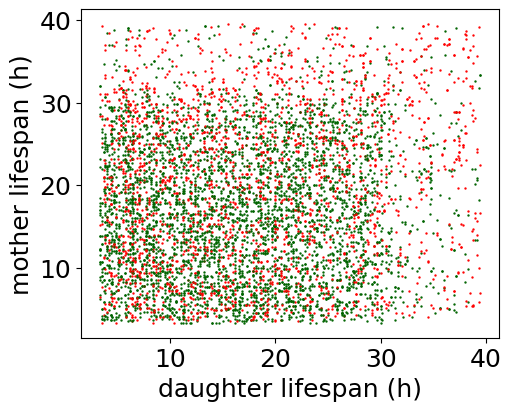

In [51]:
def mother_daughter_lifespan(graph):
    cutofflen=20
    divs=[v for v in graph.nodes() if (graph.out_degree(v)==2)] # and graph.nodes[v]['division_NAME']=='true')]
    lfs1,lfs2=[],[]
    divs_included=[]
    print("n_divs = ",len(divs))
    for v0 in divs:
        v=v0
        mother=[]
        while True:
            mother.append(v)
            v=list(graph.predecessors(v))
            #if (len(v)>1):
            #    xxx
            if len(v)==0:
                break
            if graph.out_degree(v[0])>1:
                mother.append(v[0])
                break
            else:
                v=v[0]
        mother=np.flip(mother)

        for v in list(graph.successors(v0)):
            daughter=[]
            while True:
                daughter.append(v)
                v=list(graph.successors(v))
                if len(v)==0:
                    break
                if graph.out_degree(v[0])>1:
                    daughter.append(v[0])
                    break
                else:
                    v=v[0]

            if (len(mother)>cutofflen and len(daughter)>cutofflen) and \
               (len(mother)< 240 and len(daughter)< 240 ):
                divs_included.append(v0)
                lfs1.append((graph.nodes[mother[-1]]['t']-graph.nodes[mother[0]]['t'])/6.)
                lfs2.append((graph.nodes[daughter[-1]]['t']-graph.nodes[daughter[0]]['t'])/6.)
#                xyt=np.array([[graph.nodes[v]['x'],graph.nodes[v]['y'],graph.nodes[v]['t']*dt] for v in mother])
#                v1 = np.mean([[xyt[i,2],np.sqrt((xyt[i+step,0]-xyt[i,0])**2 + (xyt[i+step,1]-xyt[i,1])**2)/(xyt[i+step,2]-xyt[i,2])] for i in range(0,len(xyt)-step,step)])
#                xyt=np.array([[graph.nodes[v]['x'],graph.nodes[v]['y'],graph.nodes[v]['t']*dt] for v in daughter])
#                v2 = np.mean([[xyt[i,2],np.sqrt((xyt[i+step,0]-xyt[i,0])**2 + (xyt[i+step,1]-xyt[i,1])**2)/(xyt[i+step,2]-xyt[i,2])] for i in range(0,len(xyt)-step,step)])
#                if (np.isfinite(v1) and np.isfinite(v2)):
#                    vvs1.append(v1/60) # um/min
#                    vvs2.append(v2/60) # um/min
    return lfs1,lfs2

#graph=dat['500uM']['graph']

tmax = {} 
fig, ax = plt.subplots(figsize=(5,4),layout='constrained')   
for k in dat3:
    graph=dat3[k]['graph']
    lfs1,lfs2=mother_daughter_lifespan(graph)
    lfs1,lfs2 = np.array([lfs1,lfs2])
    # set the x,y limits based on the longest mother and daughter trajectory
    # plus some cropping, just to avoid 
    tmax = max(lfs1+lfs2)/2*0.95
    #cnd = lfs1+lfs2 < 0.95*(lfs1+lfs2)
    cnd = (lfs1<tmax) & (lfs2 <tmax)
    print(k,tmax)
    lfs1,lfs2 = lfs1[cnd],lfs2[cnd]
    ax.scatter(lfs1,lfs2,s=0.5,c='red' if '500uM' in k else 'darkgreen')
    print(k,stats.pearsonr(lfs1,lfs2))
#ax.set_ylim(0,40)
#ax.set_xlim(0,42)
ax.set_ylabel("mother lifespan (h)")
ax.set_xlabel("daughter lifespan (h)")
#plt.savefig(currdir+'\\mother_daugther_speed.png',dpi=300)
#plt.savefig('/tmp/mother_daugther_speed_new.svg')
plt.show()            

# Fig. SI 2B: volume vs time 

In [92]:
import numpy.linalg as LA
def get_ellipse_axes(x): 
    v = LA.eigvals(np.array([[x['c_11'],x['c_12'],0],
                             [x['c_12'],x['c_22'],0],
                             [0,0,x['c_33']],
                            ])
                  )
    return np.sqrt(np.sort(v))[1:]

# this works on the spots list
def get_area(x):
    a,b=get_ellipse_axes(x)
    return 3.141*a*b


graph=dat2['control1']['graph']
trajs=get_all_trajs(graph)

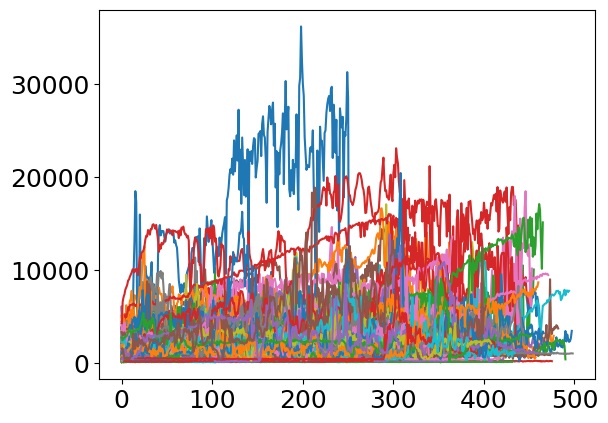

In [93]:
for tr in trajs:
    if (len(tr)>300):
        vols=[get_area(graph.nodes[v]) for v in tr]
        plt.plot(vols)
plt.show()

In [94]:
vols=[]
for tr in trajs:
    if (len(tr)>300):
        vols.append([[graph.nodes[v]['t'],get_area(graph.nodes[v])] for v in tr])

x,y,err=average_over_x(vols,1)
plt.plot(x,y)
plt.show()

1515.715754751971

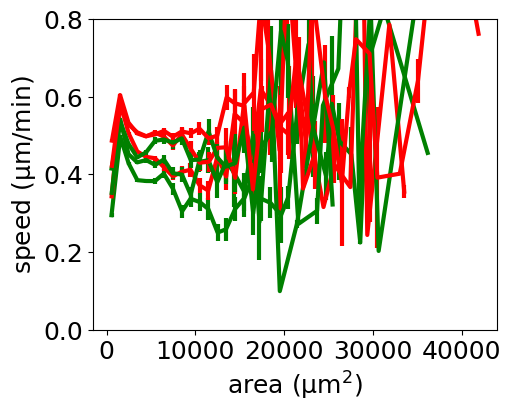

In [46]:
# this plot is not saved - there is another one in a separate notebook

def average_over_x(data,binx=1):
    data=np.array(data)
    # averages data[i] = [x[i],y[i]] over x
    ylist=[[] for i in range(0,int(max(data[:,0])/binx)+1)]
    xlist=[[] for i in range(0,int(max(data[:,0])/binx)+1)]
    for d in data:
        i=int(d[0]/binx)
        ylist[i].append(d[1])
        xlist[i].append(d[0])
    x=np.array([np.mean(xl) for xl in xlist if len(xl)>0])
    y=np.array([np.mean(yl) for yl in ylist if len(yl)>0])
    err=np.array([np.std(yl)/np.sqrt(1.*len(yl)) for yl in ylist if len(yl)>0])
    return x,y,err

fig,ax = plt.subplots(figsize=(5,4),layout='constrained',squeeze=False)
for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)

    area_vs_speed=[]
    for tr in trajs:
        if (len(tr)>200):
            #tr=[v for v in tr if (dt*graph.nodes[v]['t']>40 and dt*graph.nodes[v]['t']<80)]
            if (len(tr)!=0):
                
                area=np.array([[dt*graph.nodes[v]['t'],get_area(graph.nodes[v])] for v in tr])
        #print(area[:,0])
                speed=np.array(get_speed_2(graph,[tr],3)[0])
        #print(speed[:,0])
                area_vs_speed.append([[area[np.argmin(np.abs(area[:,0]-t)),1],s] for t,s in speed])
        #print([s for s in speed if int(s[0]) in area[:,0]])
    area_vs_speed=np.concatenate(area_vs_speed)
    #ax[0][0].scatter(area_vs_speed[:,0],area_vs_speed[:,1],s=1,c=col[e])
    
    x,y,err = average_over_x(area_vs_speed,binx=1000)

    ax[0][0].errorbar(x,y,err,lw=3,color=col[e],label=dat2[e]['label'])
    ax[0][0].set_ylim(0,0.8)
    
ax[0][0].set_xlabel('area ($\mathrm{\mu}$m$^2$)')
ax[0][0].set_ylabel('speed ($\mathrm{\mu}$m/min)')
#plt.savefig('../figures/plots/speed_vs_area_3reps.svg')
plt.show()

# Fig. sup 3B.

In [19]:
## all cells are pooled together irrespectively of their fluorescence
dat54_500um_hf,fluos_500um_hf =  pool_dat([dat54_500um_high,dat54_500um_high_F5],[dat_fluo54_500um_high,dat_fluo54_500um_high_F5] )
dat54_500um_lf,fluos_500um_lf =  pool_dat([dat54_500um_low,dat54_500um_low_F5],[dat_fluo54_500um_low,dat_fluo54_500um_low_F5] )
dat54_control_hf,fluos_control_hf =  pool_dat([dat54_control_high,dat54_control_high_C5],[dat_fluo54_control_high,dat_fluo54_control_high_C5] )
dat54_control_lf,fluos_control_lf =  pool_dat([dat54_control_low ,],[dat_fluo54_control_low,] )


dat54_hf,fluos54_hf =  pool_dat([dat54_500um_hf,dat54_control_hf],[fluos_500um_hf,fluos_control_hf] )
dat54_lf,fluos54_lf =  pool_dat([dat54_500um_lf,dat54_control_lf],[fluos_500um_lf,fluos_control_lf] )

dat54_allcontrols,dat_fluo54_allcontrols =  pool_dat([dat54_control_high,dat54_control_low,dat54_control_high_C5,dat54_control_low],
                                                     [dat_fluo54_control_high,dat_fluo54_control_low,dat_fluo54_control_high_C5,dat_fluo54_control_low],
                                                    )


dat54_alltreated,dat_fluo54_alltreated =  pool_dat([dat54_500um_high,dat54_500um_low,dat54_500um_high_F5,dat54_500um_low],
                                                     [dat_fluo54_500um_high,dat_fluo54_500um_low,dat_fluo54_500um_high_F5,dat_fluo54_500um_low],
                                                )

/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


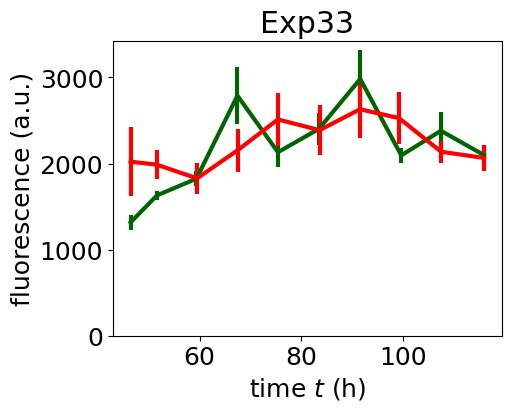

In [20]:

dat_to_compare = {'fluo_timeseries_control_vs_treated':(
                          [dat54_allcontrols,dat_fluo54_allcontrols,'controls','darkgreen'],
                           [dat54_alltreated,dat_fluo54_alltreated,'treated','red']),
                }
for figname,dats in dat_to_compare.items():
    fig,ax = plt.subplots(1,figsize=(5,4),layout='constrained')
    for i,(dat,fluo,lab,color) in enumerate(dats):

        fluo_by_node = get_fluo_by_node(fluo)
        fluo_tracks = get_fluo_track(dat,fluo_by_node)

        times = dat[1]
        times_new = [ np.minimum(e,24*60*5 - 60) for e in times]
        times_bin,fluo_bin,fluo_stderr = bin_xy_data(list(zip(times_new,fluo_tracks)),qx=8*60,dropnan=True)

        to_shift = times_bin == 5 
        ax.errorbar(np.array(times_bin)/60,fluo_bin,fluo_stderr,color=color,lw=3)
        ax.set_ylabel('fluorescence (a.u.)')
        ax.set_xlabel('time $t$ (h)')
        ax.set_ylim(0)
        ax.set_title(exp_label)

    plt.savefig(f'./plots/{figname}.svg')